In [ ]:
import os
from google.colab import drive
from PIL import Image
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import hashlib

In [29]:
drive.mount('/content/drive')

#verification du chemin
os.listdir('/content/drive/MyDrive/driver-distraction-detection')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['data', 'models', 'src', 'config', 'notebooks', 'results']

In [ ]:
#Statistiques du dataset
DATASET_PATH = "/content/drive/MyDrive/driver-distraction-detection/data/"

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")
LABEL_EXTENSIONS = (".csv",)

total_size = 0
image_count = 0
label_count = 0

for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        file_path = os.path.join(root, file)
        file_size = os.path.getsize(file_path)
        total_size += file_size

        if file.lower().endswith(IMAGE_EXTENSIONS):
            image_count += 1
        elif file.lower().endswith(LABEL_EXTENSIONS):
            label_count += 1

total_size_mb = total_size / (1024 ** 2)


# Résultats
print("STATISTIQUES DU DATASET")
print(f"Nombre total d’images      : {image_count}")
print(f"Nombre total d’annotations : {label_count}")
print(f"Taille totale du dataset   : {total_size_mb:.2f} MB")

if image_count > 0:
    print(f"Taille moyenne par image   : {total_size_mb * 1024 / image_count:.2f} KB")


STATISTIQUES DU DATASET
Nombre total d’images      : 22424
Nombre total d’annotations : 4
Taille totale du dataset   : 911.50 MB
Taille moyenne par image   : 41.62 KB


In [ ]:
#Calcul de nombre d'images par classe
def check_dataset(base_path):
    report = {}
    classes = os.listdir(base_path)
    for cls in classes:
      cls_path = os.path.join(base_path, cls)
      if os.path.isdir(cls_path):
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(IMAGE_EXTENSIONS)]
        report[cls] = len(images)

    return report


d = check_dataset('/content/drive/MyDrive/driver-distraction-detection/data/raw')
print("nombre d'images par classe: ")
for cls , item in d.items():
  print(f"{cls}: {item}")



nombre d'images par classe: 
c0_safe_driving: 2489
c1_texting_right: 2267
c2_talking_phone_right: 2317
c3_texting_left: 2346
c4_talking_phone_left: 2326
c5_operating_radio: 2312
c6_drinking: 2325
c7_reaching_behind: 2002
c8_hair_makeup: 1911
c9_talking_passenger: 2129


In [ ]:
#Différentes tailles des images du dataset
def check_image_sizes(folder):
    sizes = {}
    for root, _, files in os.walk(folder):
        for f in files:
            if f.endswith(('.jpg','.png','.jpeg')):
                path = os.path.join(root, f)
                img = Image.open(path)
                sizes.setdefault(img.size, 0)
                sizes[img.size] += 1
    return sizes
print(check_image_sizes('/content/drive/MyDrive/driver-distraction-detection/data/raw'))

In [ ]:
#Vérification de compatibilité des images et labels
IMAGES_DIR = "/content/drive/MyDrive/driver-distraction-detection/data/raw"
LABELS_DIR = "/content/drive/MyDrive/driver-distraction-detection/data/annotations/all_labels_complete.csv"

image_names = set()
for class_folder in os.listdir(IMAGES_DIR):
    class_path = os.path.join(IMAGES_DIR, class_folder)
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.lower().endswith(IMAGE_EXTENSIONS):
                image_names.add(f"{class_folder}/{os.path.splitext(file)[0]}")

df = pd.read_csv(LABELS_DIR)
label_names = set(df["image_path"].apply(lambda x: os.path.splitext(x)[0]).astype(str))

# Vérifications
images_without_labels = image_names - label_names
labels_without_images = label_names - image_names

print("Vérifications:")

if not images_without_labels and not labels_without_images:
    print("Chaque image possède un label unique.")
else:
    if images_without_labels:
        print("Images sans label :")
        for name in sorted(images_without_labels):
            print(f"   - {name}")
    if labels_without_images:
        print("Labels sans image correspondante :")
        for name in sorted(labels_without_images):
            print(f"   - {name}")


Vérifications:
Chaque image possède un label unique.


In [ ]:
#Visualisations des images echantillons de chaque classe
%matplotlib inline
SAMPLES_PER_CLASS = 3

class_folders = [f for f in os.listdir(IMAGES_DIR) if os.path.isdir(os.path.join(IMAGES_DIR, f))]
num_classes = len(class_folders)

# Création d'une grille 2D pour axes
fig, axes = plt.subplots(num_classes, SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS*4, num_classes*4))
fig.tight_layout(pad=3.0)

axes = np.atleast_2d(axes)

for row_idx, class_folder in enumerate(class_folders):
    class_path = os.path.join(IMAGES_DIR, class_folder)
    images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    if not images:
        continue

    sample_images = random.sample(images, min(SAMPLES_PER_CLASS, len(images)))

    for col_idx in range(SAMPLES_PER_CLASS):
        ax = axes[row_idx, col_idx]
        if col_idx < len(sample_images):
            img_path = os.path.join(class_path, sample_images[col_idx])
            try:
                img = mpimg.imread(img_path)
                ax.imshow(img)
                ax.set_title(class_folder)
            except:
                ax.text(0.5, 0.5, 'Erreur lecture', ha='center', va='center')
        ax.axis('off')

plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Recherche des images dupliquées
def find_duplicates(folder):
    hashes = {}
    duplicates = []

    for root, _, files in os.walk(folder):
        for f in files:
            if f.endswith(('.jpg','.png','.jpeg')):
                path = os.path.join(root, f)
                with open(path, 'rb') as file:
                    h = hashlib.md5(file.read()).hexdigest()
                if h in hashes:
                    duplicates.append((path, hashes[h]))
                else:
                    hashes[h] = path
    return duplicates
print(find_duplicates(IMAGES_DIR))

[]


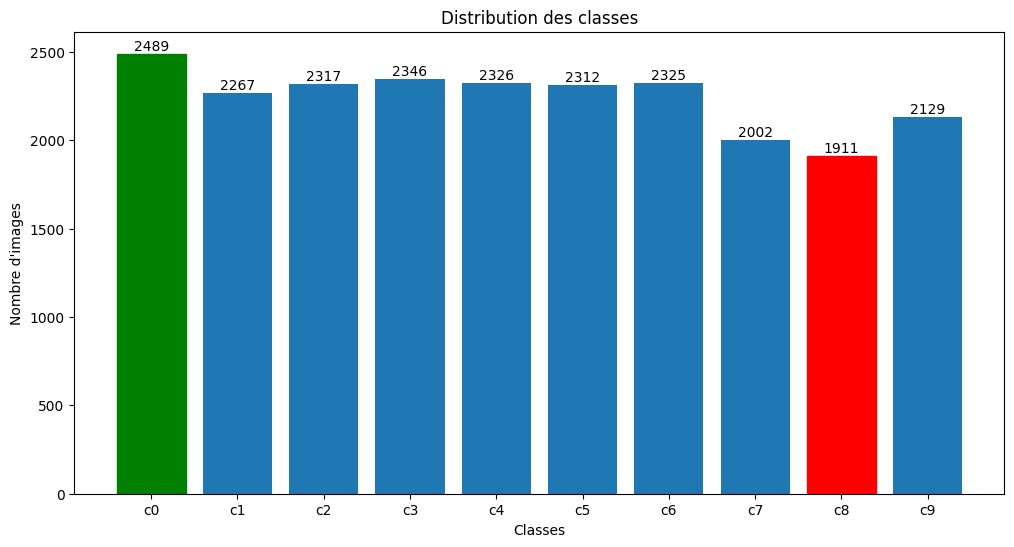

In [42]:
#Visualisations des classes par nombre des images
classes = ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
counts =  check_dataset(IMAGES_DIR).values()

plt.figure(figsize=(12, 6))
bars = plt.bar(classes, counts)
plt.xlabel('Classes')
plt.ylabel('Nombre d\'images')
plt.title('Distribution des classes')

bars[0].set_color('green')  # Classe majoritaire
bars[8].set_color('red')    # Classe minoritaire

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center')